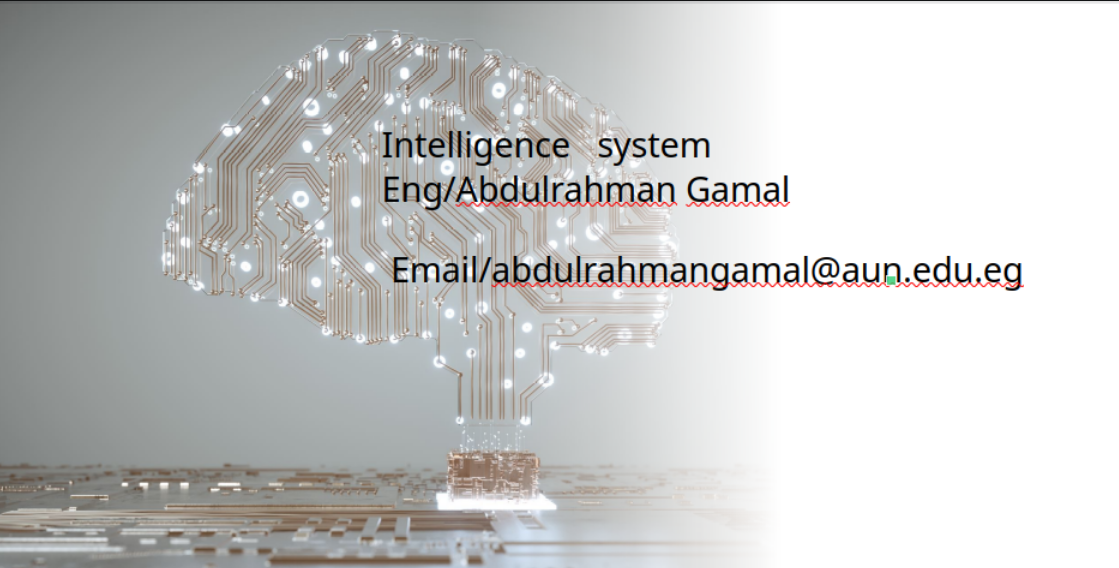

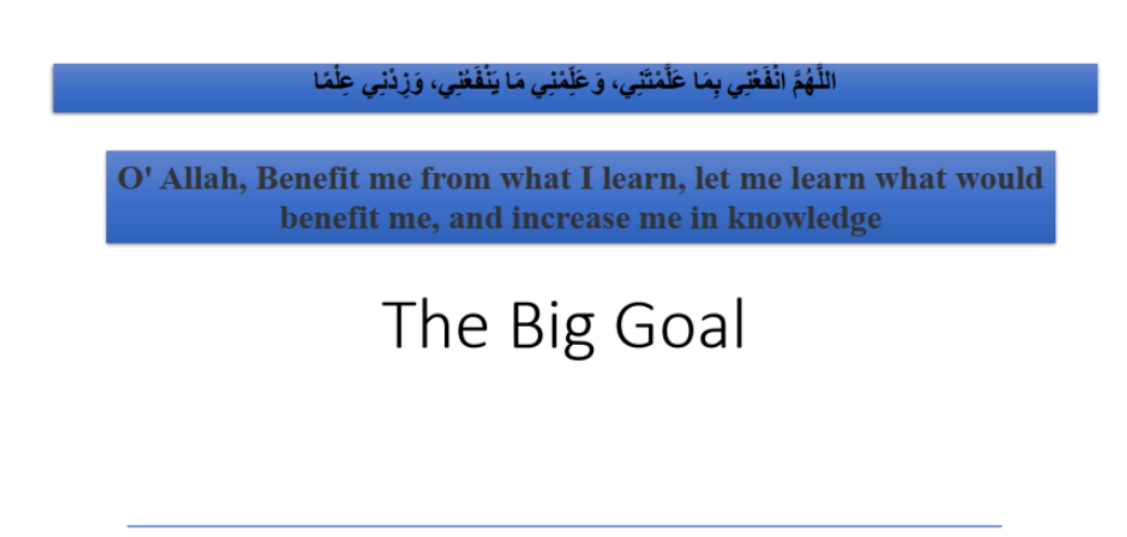

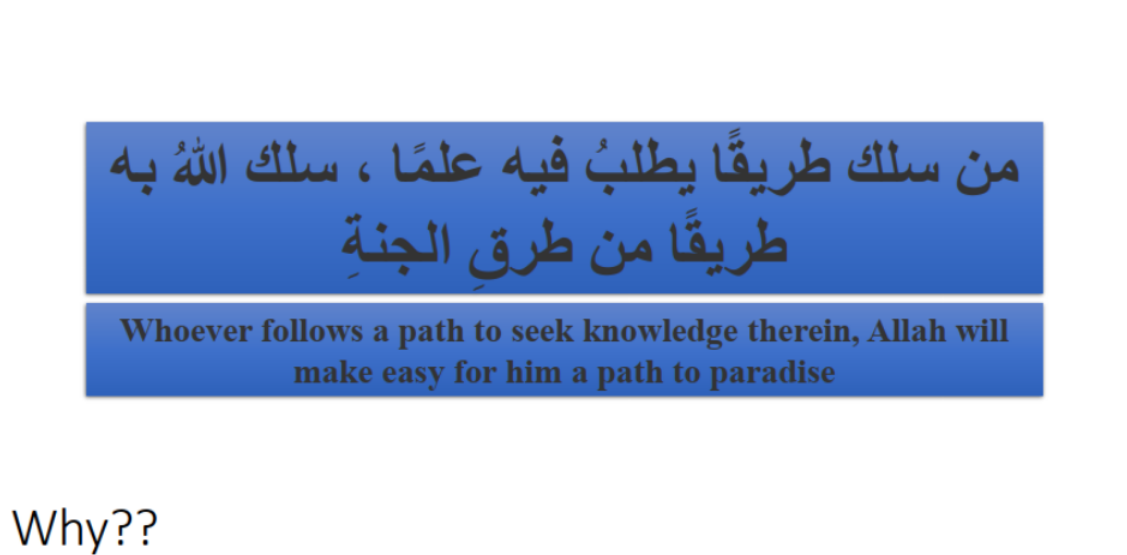

# What is  Agent ?

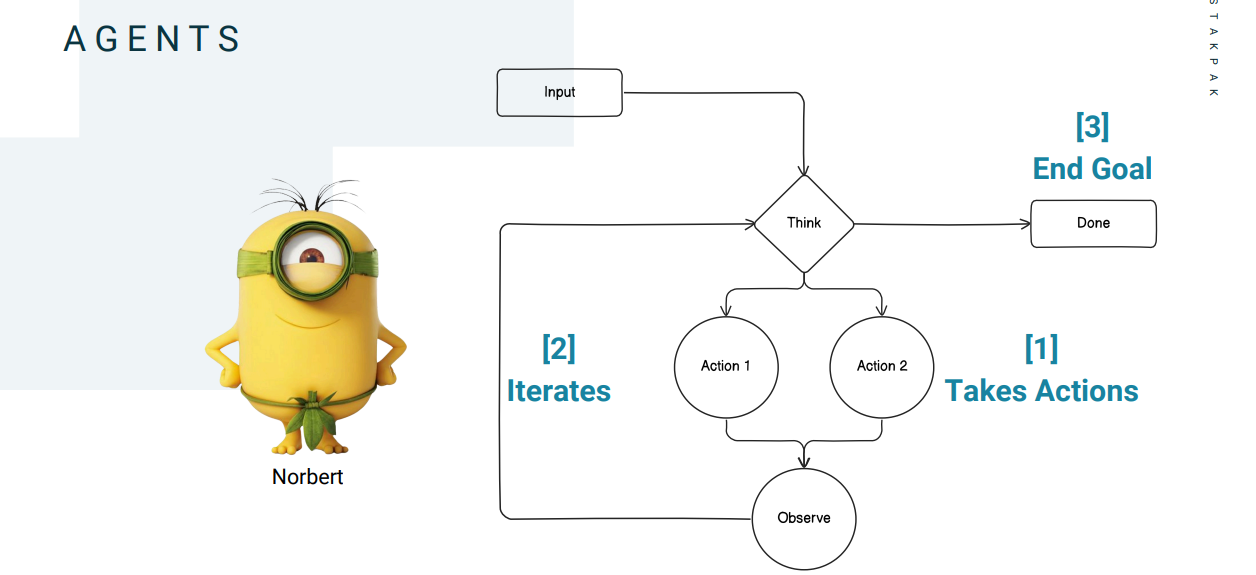

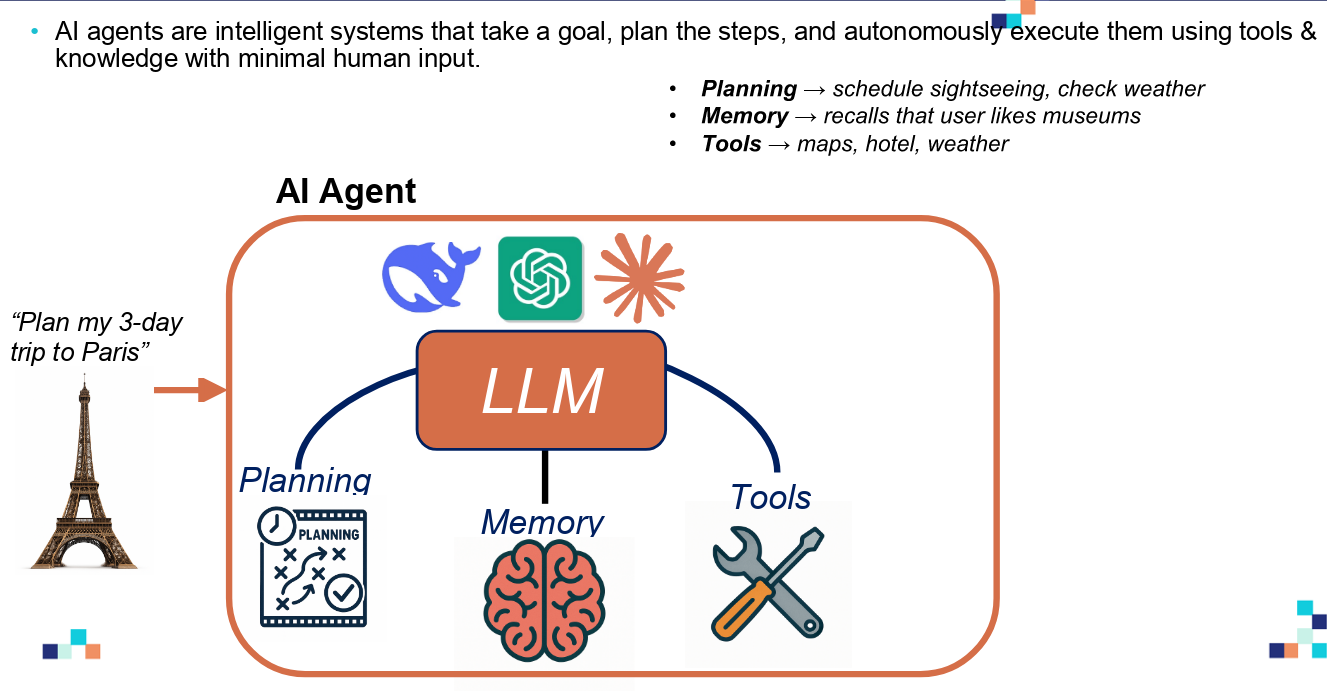

# Do you need Agents? 

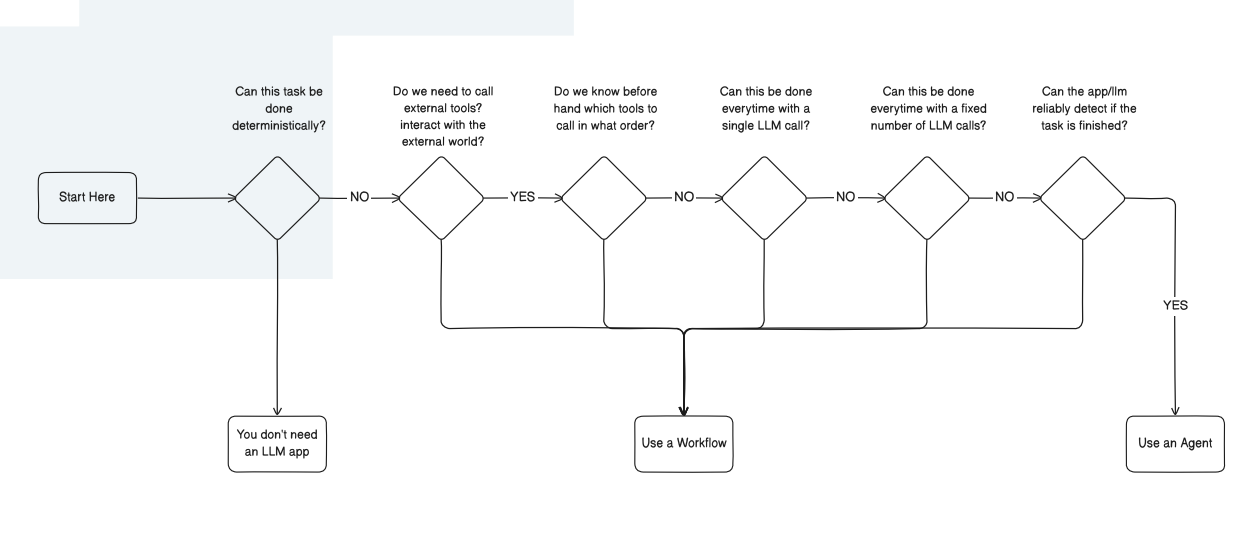

# TASK 1.  OVERVIEW

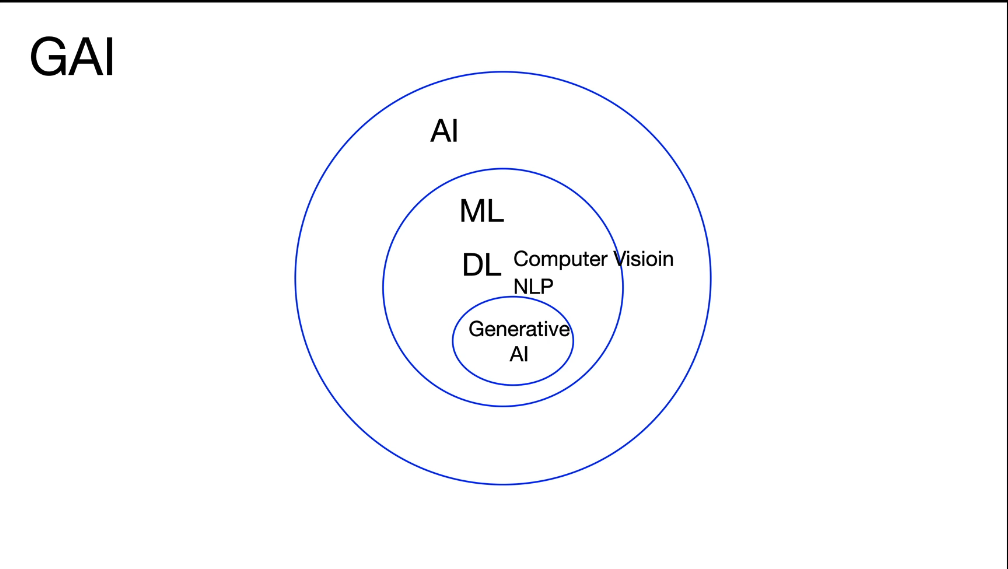

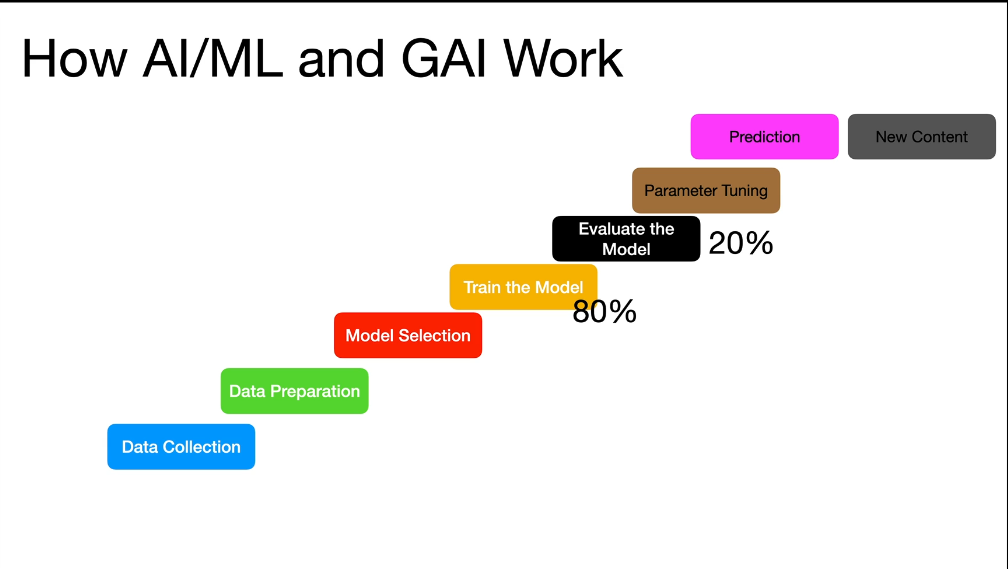

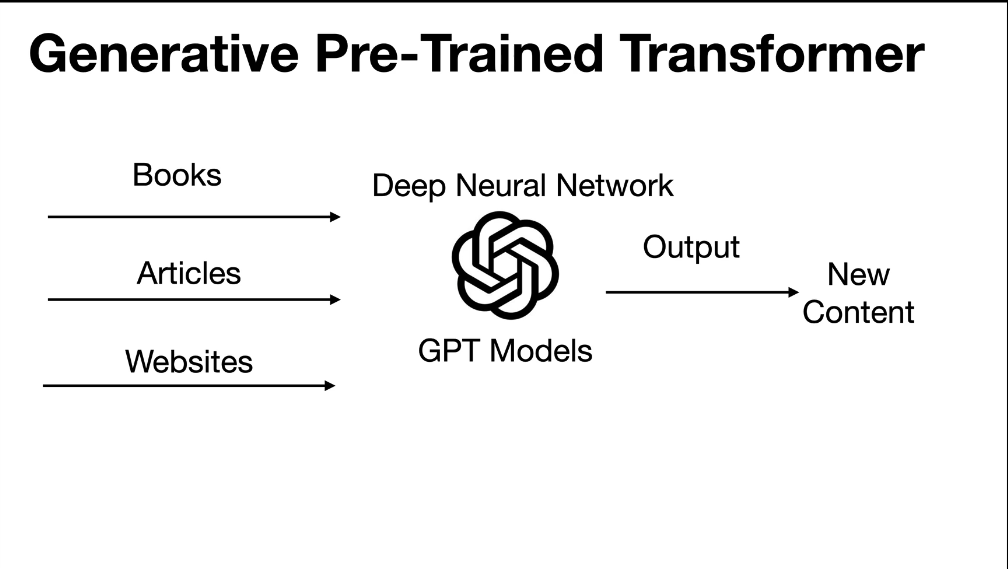

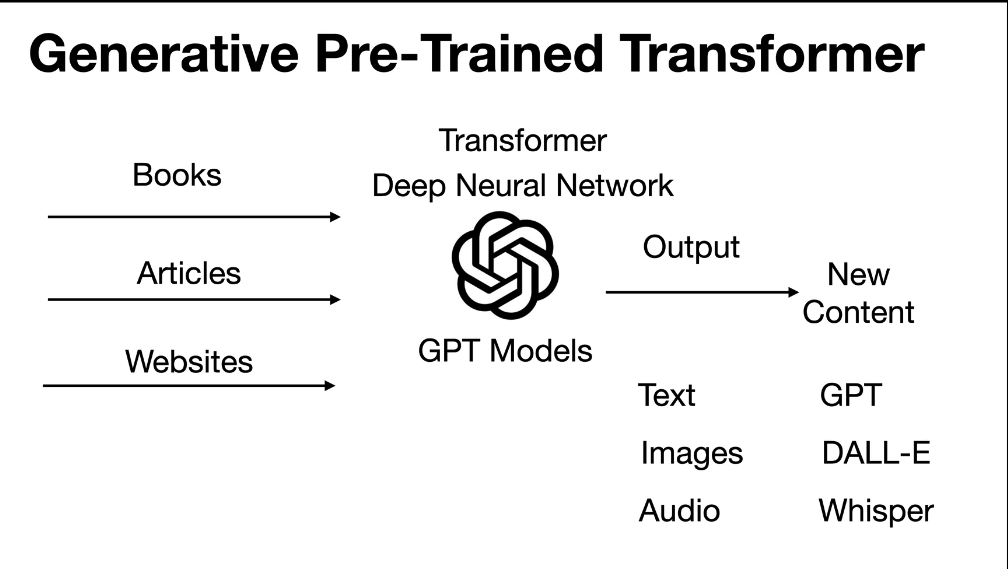

## First LLM

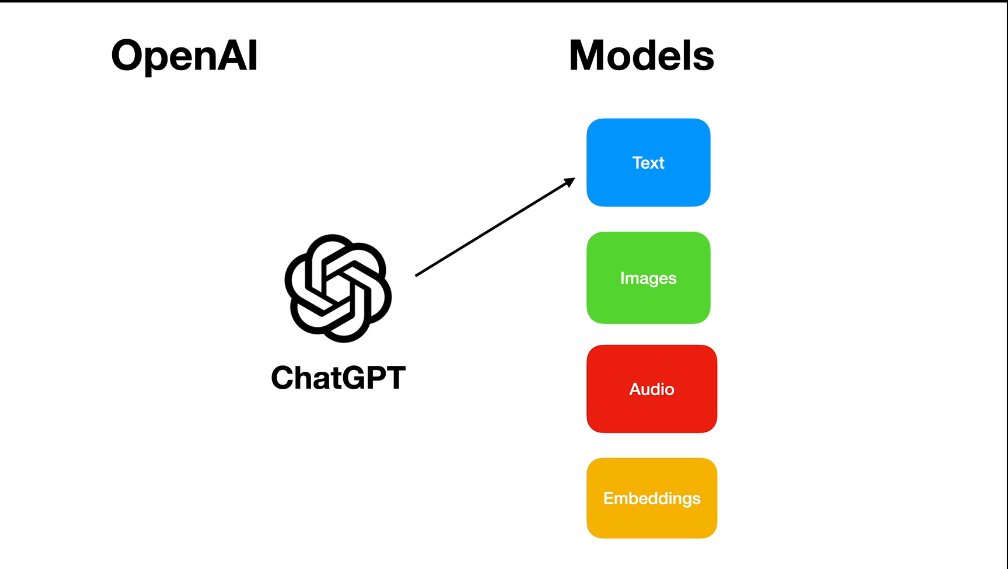

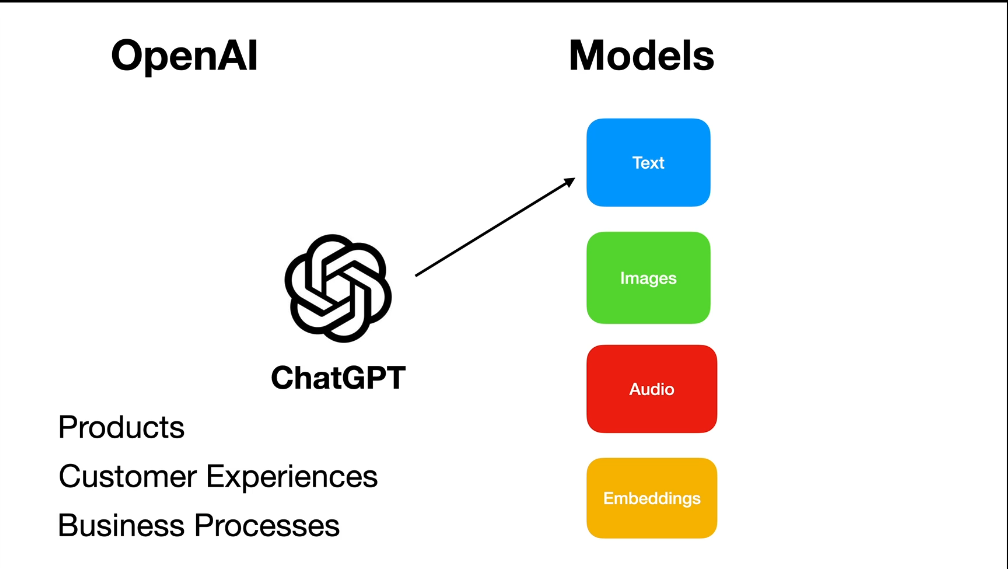

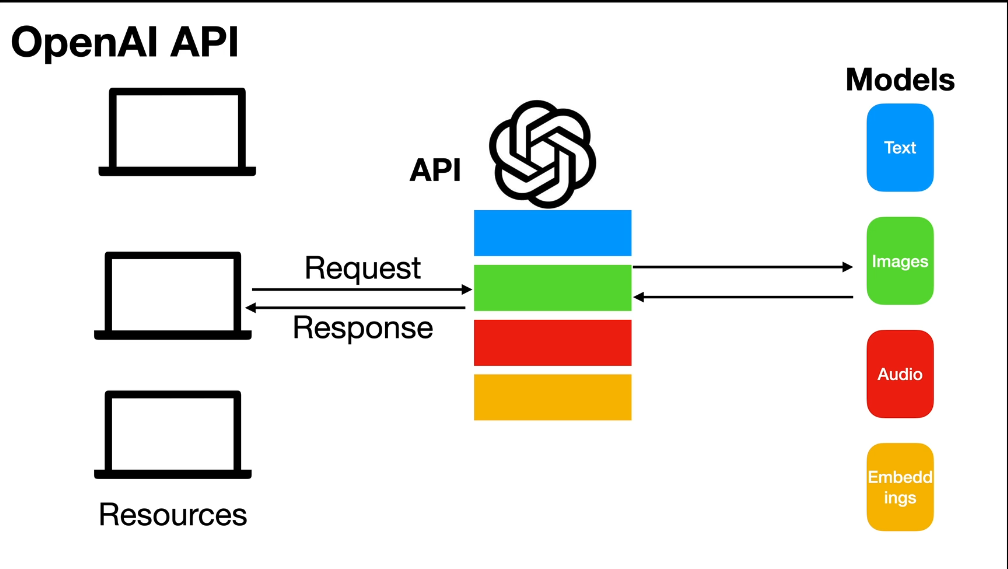

## OTher LLMs

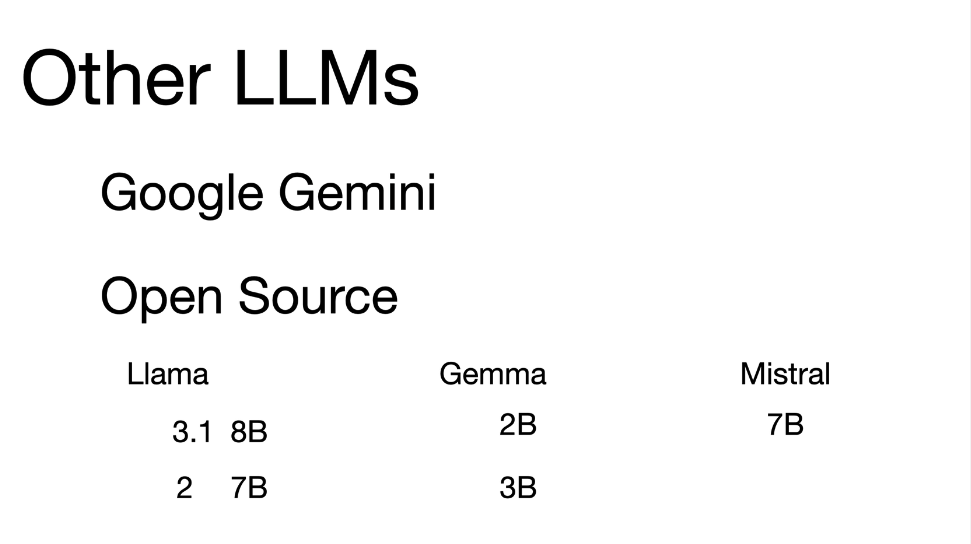


` 7B need 8 GB Ram ` , `13 Need 16 GB ram` , `33 need 32GB  Ram`

## How to  download open Source model

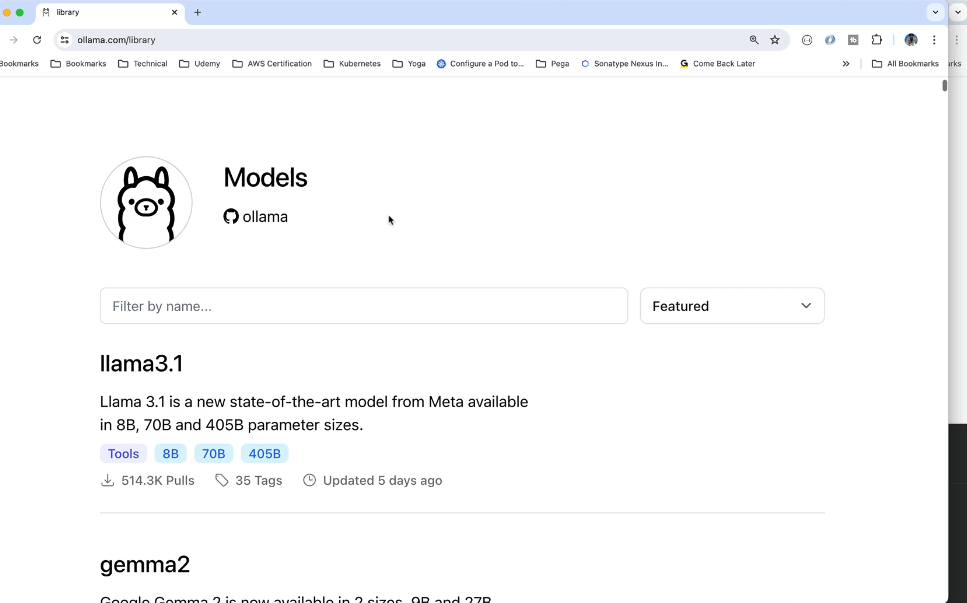

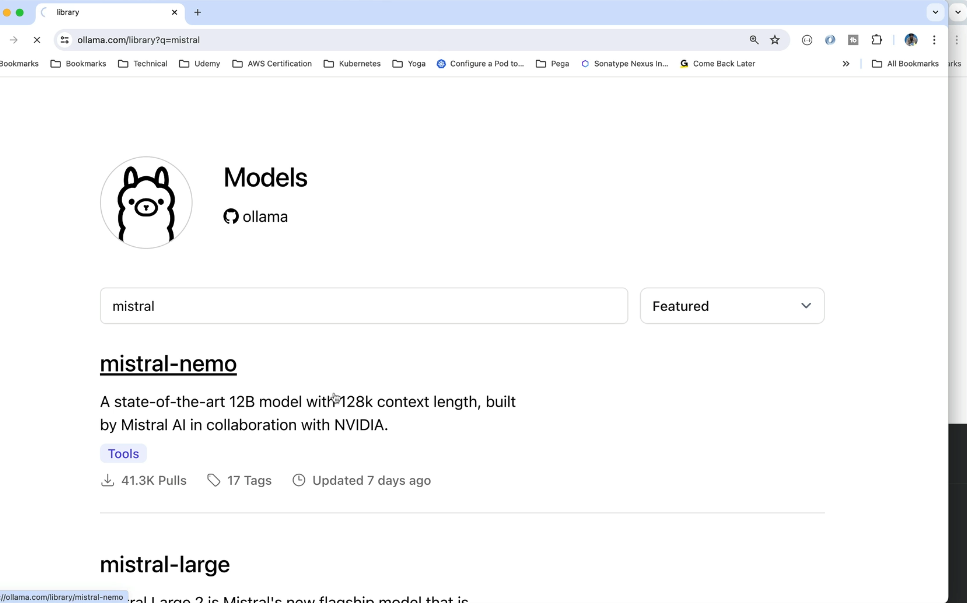

## langchain 

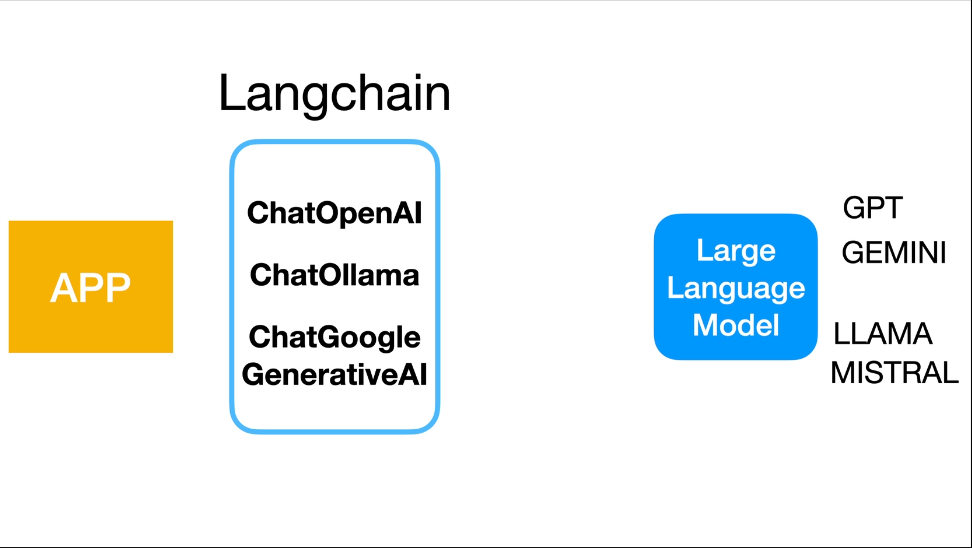

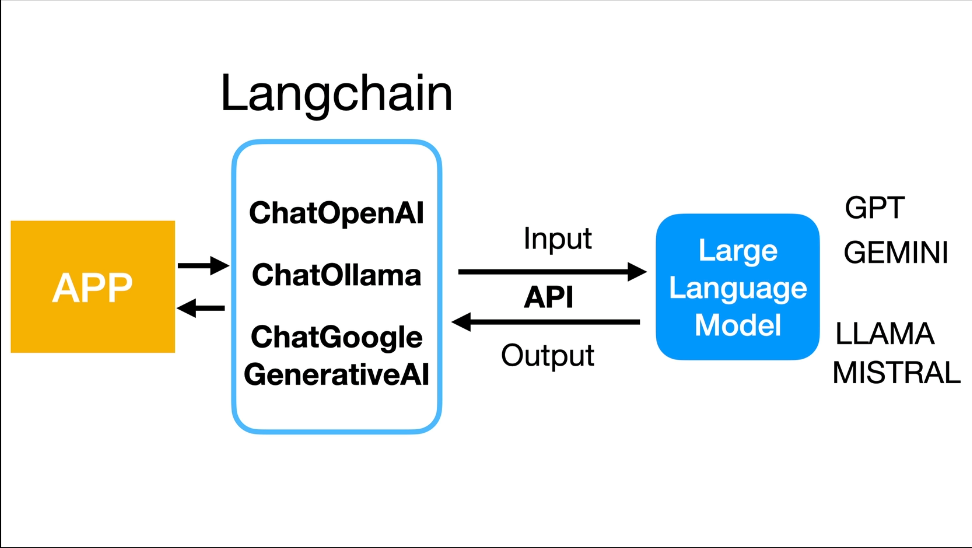


When we use these classes behind the scenes, Lang Chain will use the appropriate API required to communicate       
with a particular large language model.Send the request that came for our application,         
get the response back and hand that output or response          

So lang chain will act as a management layer between our application and the large language models,         

And it is very easy to switch from one class to another.If you are switching LLMS at a point later on,

# what is the change when change LLM ?

only the two line

## call Google llms   (free and we use it )

In [1]:
#from langchain_google_genai import ChatGoogleGenerativeAI
#llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


## call Local LLMs  (free and you can use it )

we do not run this cell as we do not have local llms till now        
Import the ChatOllama class from the LangChain community package      

In [2]:
#from langchain_community.chat_models import ChatOllama            
#llm = ChatOllama(model="gemma:2b")


## call openAi  (not free not use it )

we do not run this cell as we do not have openai api key till now .env     
because I does not have money to fund the account and openai does not have free tier .   

In [3]:
#from langchain_openai import ChatOpenAI
#llm = ChatOpenAI(model="gpt-4o")


# TASK 2. CONFIGURE GOOGLE API  and RUN Model 

Before we can build our first AI agent, we need two things:

1. The `GOOGLE-agents` library installed.  
2. Your secret Google API key to communicate with the AI models.

> **Security tip 📌** Store keys securely in a `.env` file. Make sure you have a file named `.env` in the same directory as this notebook with your key:
>
> ```dotenv
> GOOGLE_API_KEY=YourSecretGoogleKeyGoesHereXXXXXXXXXXXXX
> ```

Let's run the cells below to install the necessary packages and load your API key.

- **You can access the GOOGLE  API here: https://aistudio.google.com/**

In [4]:
# Uninstall lib- if you have it installed 
!pip uninstall -y langchain-openai  # not needed  
!pip uninstall -y langchain-google-genai langchain-core langchain

Found existing installation: langchain-google-genai 4.2.2
Uninstalling langchain-google-genai-4.2.2:
  Successfully uninstalled langchain-google-genai-4.2.2
Found existing installation: langchain-core 1.3.0
Uninstalling langchain-core-1.3.0:
  Successfully uninstalled langchain-core-1.3.0
Found existing installation: langchain 1.2.15
Uninstalling langchain-1.2.15:
  Successfully uninstalled langchain-1.2.15


In [ ]:
! pip install langchain-google-genai langchain-core langchain --no-cache-dir

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [langchain]/3 [langchain]google-genai]


#### why need to  this four ? 
1) langchain-google-genai ,   
2) langchain-core ,   
3) langchain ,    
4) --no-cache-dir   


1. langchain-core (The Engine / Foundation)
This is the absolute base of the library. It doesn't contain any advanced tools or AI models; it only contains the basic rules of how data moves around (like what a "System Message" or "Human Message" is). Everything else relies on this.

2. langchain (The Body / Framework)
This is the main structural framework. It contains all the logic for building Agents, creating memory, and designing workflows. But on its own, it doesn't know how to talk to any specific company like Google or OpenAI.

3. langchain-google-genai (The Translator / Adapter)
This is the specific adapter that knows how to connect the langchain framework to Google's servers. It takes your LangChain code and translates it into a language that the Gemini API understands.

4. --no-cache-dir (The "Fresh Start" Command)
Normally, when you download a package, your computer saves a hidden copy (a cache) so it can install it faster next time. Because your previous installation was causing errors, we added this command to tell your system: "Do NOT use the old, saved files. Go to the internet and download a brand new, clean copy of everything."

Why write them ALL on the exact same line?
This is the most important part.

If you install them one by one (e.g., pip install langchain-core, and then later pip install langchain), the Python package manager (pip) might accidentally download versions that do not match up.

By putting them all on the exact same line, you force pip to act like a puzzle solver. It looks at all three libraries at the exact same time and says: "I need to find the specific versions of Core, LangChain, and Google-GenAI that perfectly match each other so they don't crash." It guarantees that all the puzzle pieces fit together perfectly on the first try.

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()


"""
What it does: It securely reads key-value pairs from a hidden local file named .env and loads them into your computer's temporary memory
as environment variables (e.g., os.environ).Why it's important: It is a security best practice. 
It allows you to use sensitive credentials (like your GOOGLE_API_KEY) in your application without hardcoding them directly
into your Python scripts,preventing accidental leaks when sharing or uploading your code to platforms like GitHub.

"""

"\nWhat it does: It securely reads key-value pairs from a hidden local file named .env and loads them into your computer's temporary memory\nas environment variables (e.g., os.environ).Why it's important: It is a security best practice. \nIt allows you to use sensitive credentials (like your GOOGLE_API_KEY) in your application without hardcoding them directly\ninto your Python scripts,preventing accidental leaks when sharing or uploading your code to platforms like GitHub.\n\n"

In [7]:

# Import the correct Google Generative AI class from LangChain
from langchain_google_genai import ChatGoogleGenerativeAI
# Initialize the Gemini model
# We are using 'gemini-2.5-flash' because it is the latest, fastest, and free for developers
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


In [8]:

# Prompt the user to enter a question
question = input("Enter your question: ")
print(question)
# Send the question to the model and generate a response
response = llm.invoke(question)

# Print only the clean text content of the response
print(response.content)

/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:2882: UserWarning: HumanMessage with empty content was removed to prevent API error
  warnings.warn(


ValueError: contents are required.

# TASK 3. BUILD & RUN YOUR FIRST AI AGENT USING Ollma 

### 1-download  and Run model from ollama (local model) in linux

Step 1: Install Ollama

Open your Linux terminal and run this single command. It will automatically download and install the Ollama engine on your system:

`curl -fsSL https://ollama.com/install.sh | sh`


Step 2: Ensure the Service is Running
Usually, the installation script automatically starts Ollama as a background background service. You can verify it is running by checking its status:

`systemctl status ollama`


(If for some reason it is not running, you can manually start it by typing ollama serve in a separate terminal window and leaving it open). or ` sudo systemctl start ollama ` ,` sudo systemctl start ollama`

Step 3: Download (Pull) an AI Model
Ollama is like a video game console, but you still need to download the games (the models). Since we used gemma:2b in our LangChain code earlier, you need to pull that specific model to your machine:

`ollama pull gemma:2b`

Step 4: Test it in the Terminal (Optional but recommended)
Before going back to Python, it is a great idea to test if the model works directly in your terminal.

`ollama run gemma:2b`


Step 5: Connect it to your LangChain Code
Now that Ollama is running quietly in the background and the gemma:2b model is downloaded, you can go straight to your Jupyter Notebook and run the code.

### 2-download  and Run model from olma (local model) in windows

1-download ollama from website

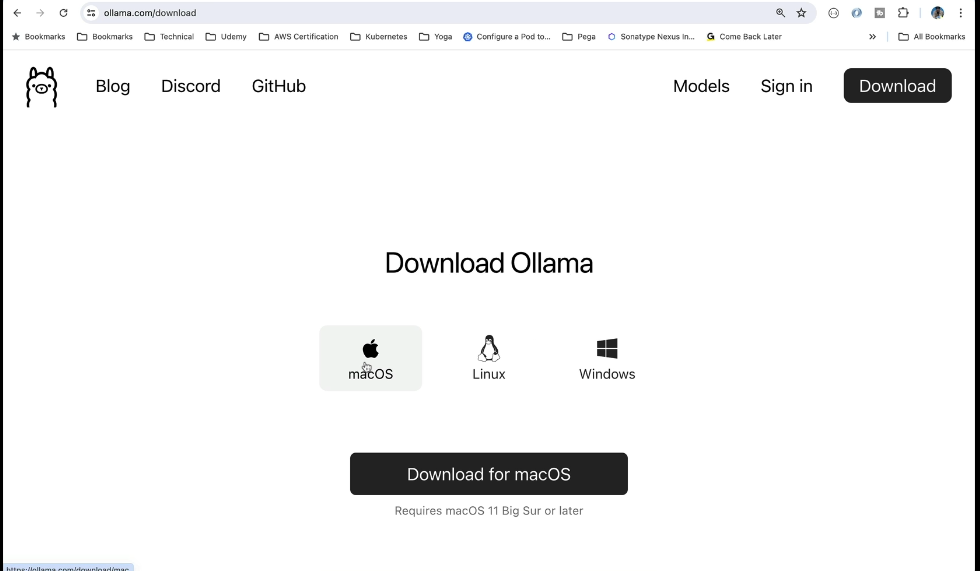

2-open cmd and type  ollama 

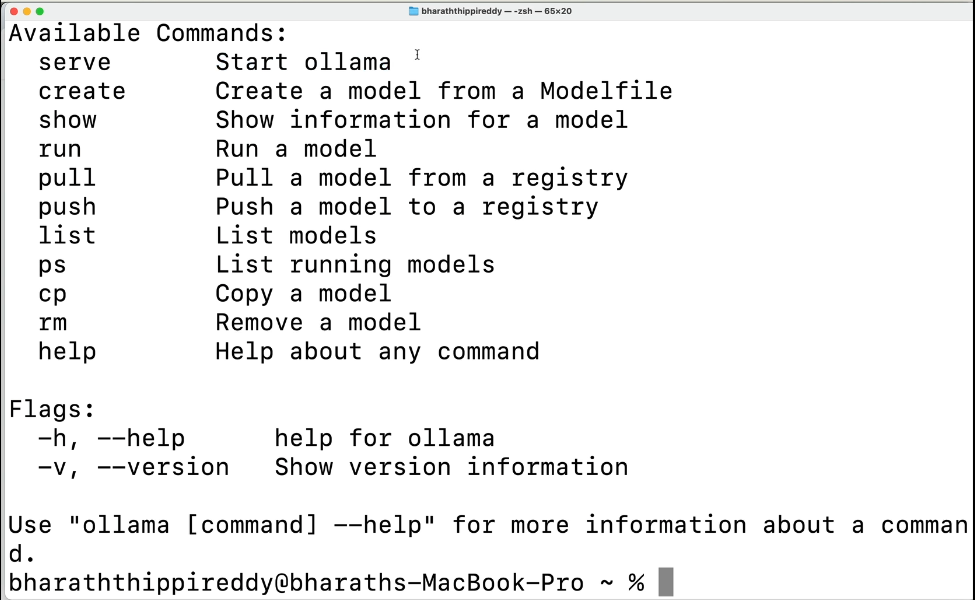

` 3-download model    `     

ollama pull gemma:2b

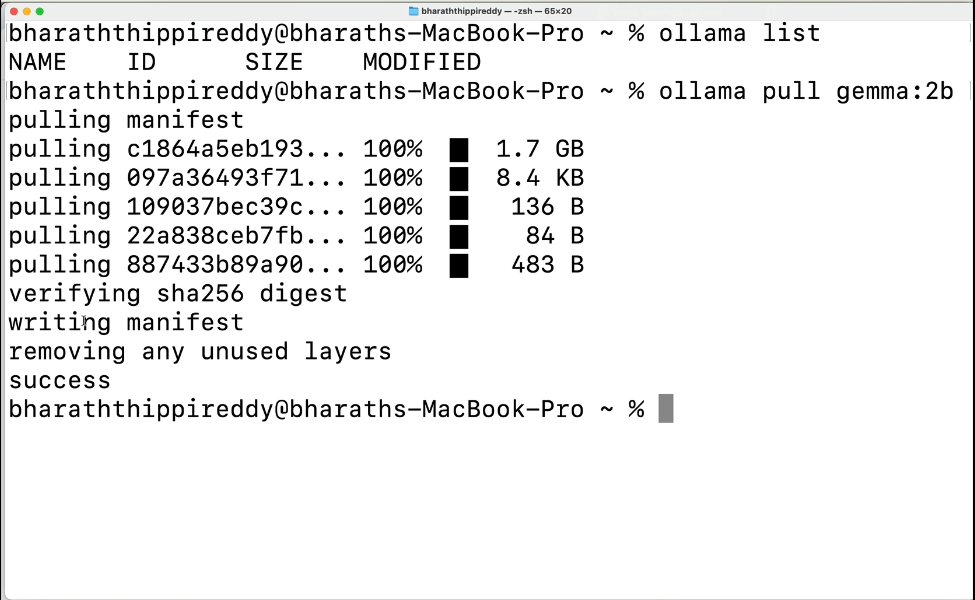

`4-run model in cmd `

ollama run gemma:2b

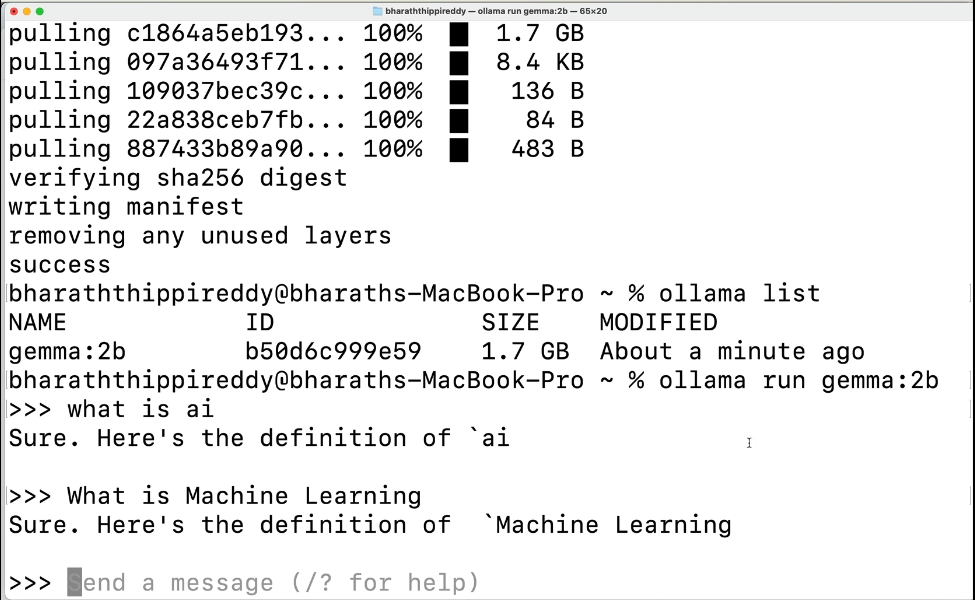

`5-remove model ` 

ollama rm modelName


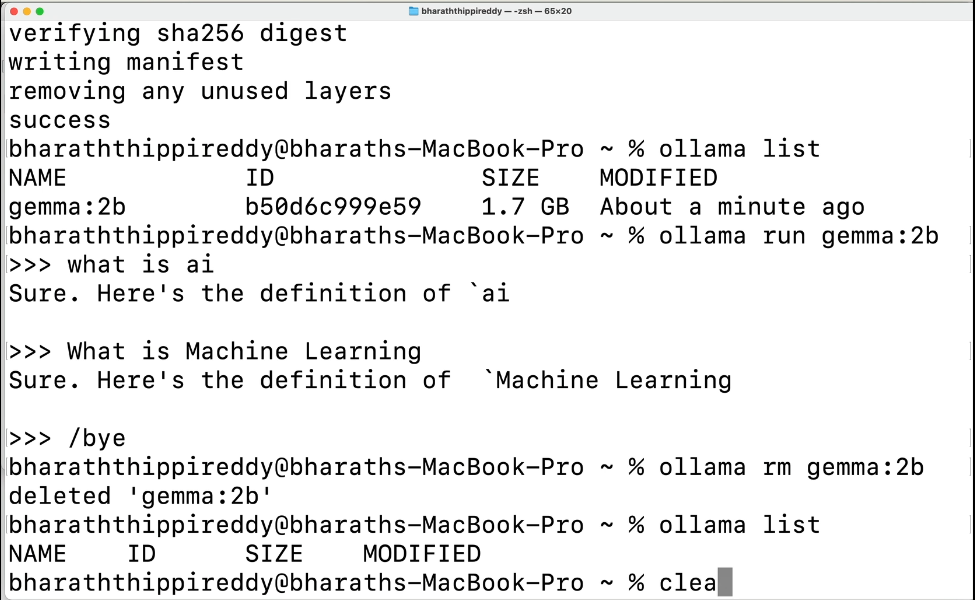

In [3]:
! pip install -U langchain-ollama

In [9]:
from langchain_ollama import ChatOllama

# LangChain will automatically look for the Ollama service running on localhost:11434
llm = ChatOllama(model="gemma:2b")

question = "In one short sentence ,How you can  help me ?" #input("Enter your question: ")
response = llm.invoke(question)

print(response.content)


I can help you by providing you with information , completing tasks for you , or offering support in any other way that would be helpful.


# Streamlit

Streamlit is a open source Python framework that we can use to build beautiful web applications or UI

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 288.5 kB/s  0:00:38m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 795.4/795.4 kB 369.6 kB/s  0:00:02eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 285.0 kB/s  0:00:36m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 303.5 kB/s  0:00:23 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 232.0 kB/s  0:00:42m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 251.0 kB/s  0:02:30m0:00:0100:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15/15 [streamlit]15 [streamlit]]


to run app must  write in terimanal:    streamlit run fileName.py 


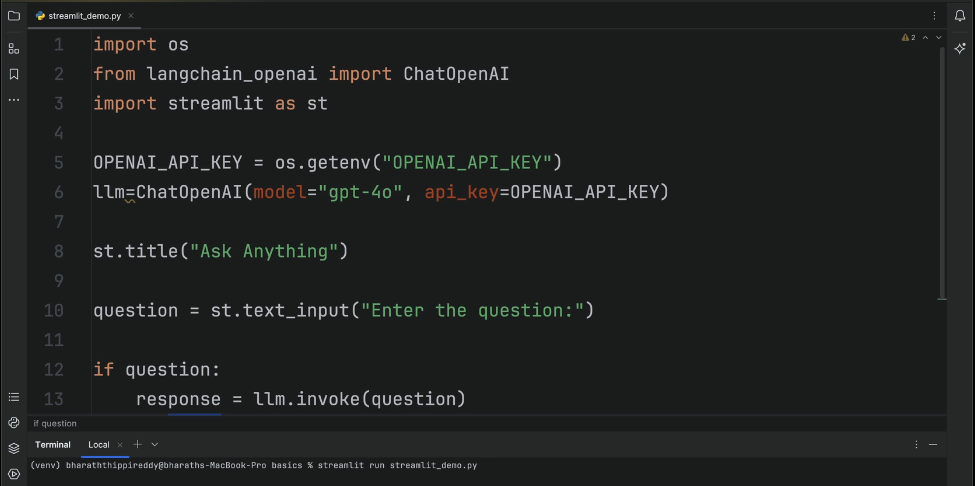

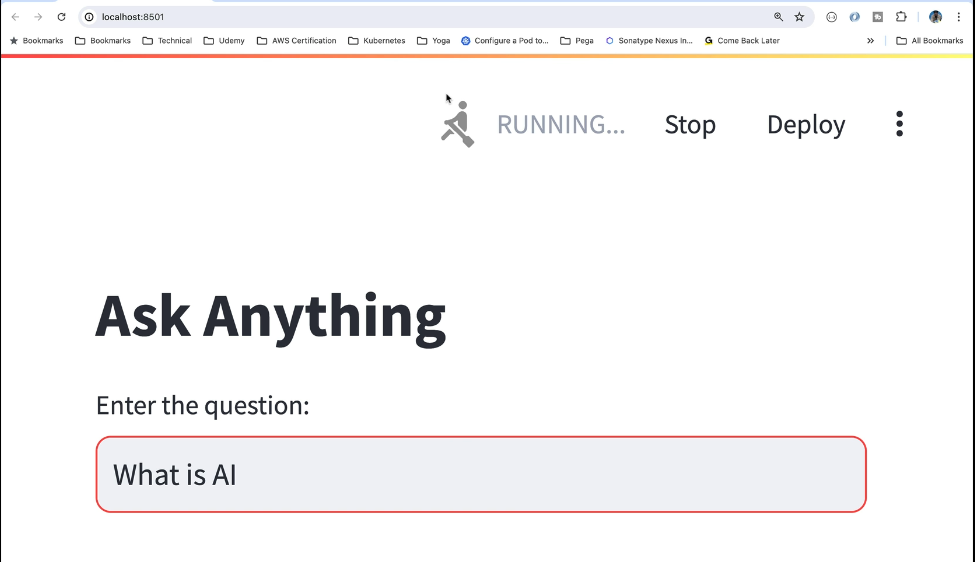

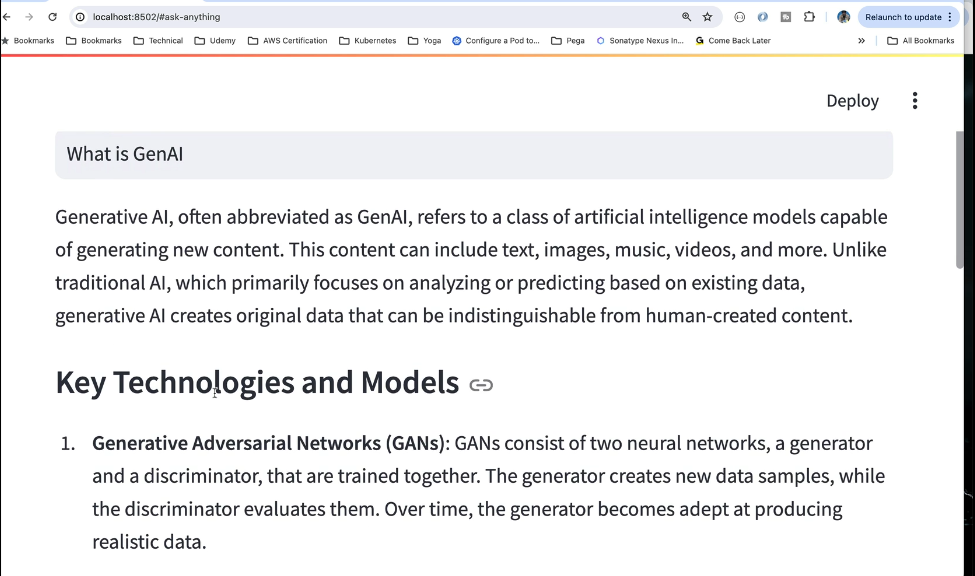

In [14]:
# if not work run it in terminal
! streamlit run streamlitApp.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.10:8501

  Stopping...
^C
  Stopping...
Exception ignored in: <module 'threading' from '/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py'>
Traceback (most recent call last):
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1560, in _shutdown
    atexit_call()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/concurrent/futures/thread.py", line 31, in _python_exit
    t.join()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1119, in join
    self._wait_for_tstate_lock()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1139, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/en

# template Prompt

A prompt template class will allow us to reuse the same prompt or instruction, while dynamically replacing

parts of it based on the user's input.

#### template have one variable

In [ ]:
# i will but this code in temp_streamlit.py file

import os
from dotenv import load_dotenv
load_dotenv()



from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate(
    input_variables=["country"],
    template="""You are an expert in traditional cuisines.
    You provide information about a specific dish from a specific country.
    Avoid giving information about fictional places. If the country is fictional
    or non-existent answer: I don't know.
    Answer the question: What is the traditional cuisine of {country}?
    """
)

import streamlit as st


st.title("Cuisine Info")

country = st.text_input("Enter the country:")

if country:
    response = llm.invoke(prompt_template.format(country=country  ))
    st.write(response.content)

In [12]:
! streamlit run temp_streamlit.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.10:8501

  Stopping...
^C
  Stopping...
Exception ignored in: <module 'threading' from '/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py'>
Traceback (most recent call last):
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1560, in _shutdown
    atexit_call()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/concurrent/futures/thread.py", line 31, in _python_exit
    t.join()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1119, in join
    self._wait_for_tstate_lock()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1139, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/en

### add more variable

In [ ]:
# i will put this code in temp_streamlit.py file

import os
from dotenv import load_dotenv
load_dotenv()



from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate(
    input_variables=["country","no_of_paras","language"],
    template="""You are an expert in traditional cuisines.
    You provide information about a specific dish from a specific country.
    Avoid giving information about fictional places. If the country is fictional
    or non-existent answer: I don't know.
    Answer the question: What is the traditional cuisine of {country}?
    Answer in {no_of_paras} short paras in {language}
    """
)

import streamlit as st


st.title("Cuisine Info")

country = st.text_input("Enter the country:")
no_of_paras = st.number_input("Enter the number of paras",min_value=1,max_value=5)
language = st.text_input("Enter the language:")

if country:
    response = llm.invoke(prompt_template.format(country=country,
                                                 no_of_paras=no_of_paras,
                                                 language=language
                                                 ))
    st.write(response.content)

2026-04-20 01:58:58.223 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 01:58:58.224 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 01:58:58.226 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 01:58:58.231 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 01:58:58.233 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 01:58:58.235 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 01:58:58.236 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 01:58:58.238 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [18]:
! streamlit run temp_streamlit.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.10:8501

^C
  Stopping...
Exception ignored in: <module 'threading' from '/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py'>
Traceback (most recent call last):
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1560, in _shutdown
    atexit_call()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/concurrent/futures/thread.py", line 31, in _python_exit
    t.join()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1119, in join
    self._wait_for_tstate_lock()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1139, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_

### improve the prompt
make model do not answer uf input is not place

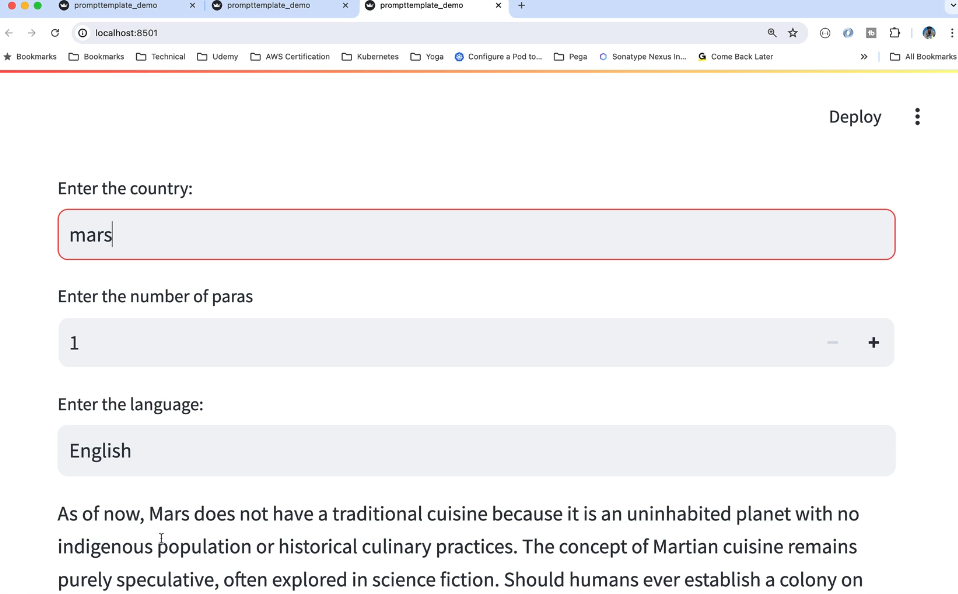

In [ ]:

import os
from dotenv import load_dotenv
load_dotenv()



from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

from langchain_core.prompts import PromptTemplate

prompt_template = PromptTemplate(
    input_variables=["country","no_of_paras","language"],
    template="""You are an expert in traditional cuisines.
    You provide information about a specific dish from a specific country.
    Avoid giving information about fictional places. If the country is fictional
    or non-existent answer: I don't know.
    Answer the question: What is the traditional cuisine of {country}?
    Answer in {no_of_paras} short paras in {language}
    """
)

import streamlit as st


st.title("Cuisine Info")

country = st.text_input("Enter the country:")
no_of_paras = st.number_input("Enter the number of paras",min_value=1,max_value=5)
language = st.text_input("Enter the language:")

if country:
    response = llm.invoke(prompt_template.format(country=country,
                                                 no_of_paras=no_of_paras,
                                                 language=language
                                                 ))
    st.write(response.content)

2026-04-20 15:06:54.223 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 15:06:54.229 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 15:06:54.248 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 15:06:54.259 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 15:06:54.270 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 15:06:54.274 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 15:06:54.277 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 15:06:54.287 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [14]:
! streamlit run temp_streamlit.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.10:8501

  Stopping...
^C
  Stopping...
Exception ignored in: <module 'threading' from '/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py'>
Traceback (most recent call last):
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1560, in _shutdown
    atexit_call()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/concurrent/futures/thread.py", line 31, in _python_exit
    t.join()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1119, in join
    self._wait_for_tstate_lock()
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/threading.py", line 1139, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/en

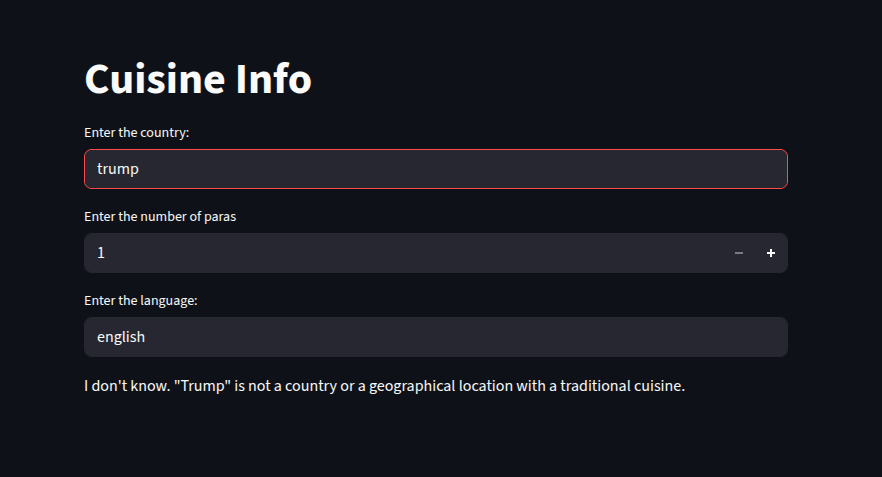

# Create a trave Guid app

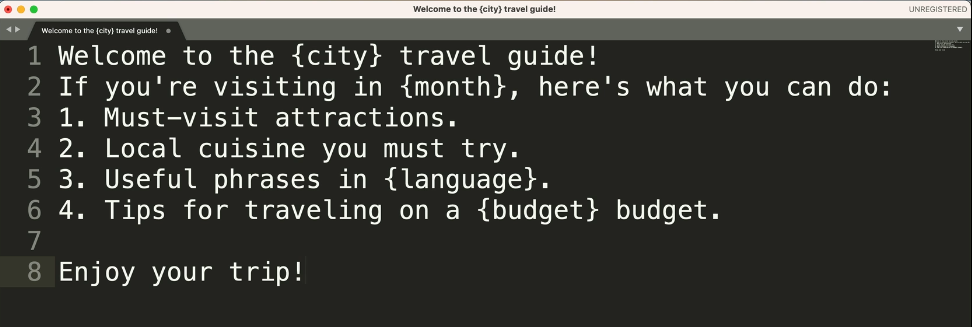

In [ ]:
# i put this code in temp_streamlit.py file to run it 
import os
from dotenv import load_dotenv
load_dotenv()



from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


from langchain_core.prompts import PromptTemplate
prompt_template = PromptTemplate(
    input_variables=["city","month","language","budget"],
    template="""Welcome to the {city} travel guide!
    If you're visiting in {month}, here's what you can do:
    1. Must-visit attractions.
    2. Local cuisine you must try.
    3. Useful phrases in {language}.
    4. Tips for traveling on a {budget} budget.
    Enjoy your trip!
    """
)

import streamlit as st

st.title("Travel Guide")

city = st.text_input("Enter the city:")
month = st.text_input("Enter the month of travel")
language = st.text_input("Enter the language:")
budget = st.selectbox("Travel Budget",["Low","Medium","High"])


if city and month and language and budget:
    response = llm.invoke(prompt_template.format(city=city,
                                                 month=month,
                                                 language=language,
                                                 budget=budget
                                                 ))
    st.write(response.content)

In [17]:
! streamlit run temp_streamlit.py


  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.10:8501

2026-04-20 15:52:10.526 Uncaught app execution
Traceback (most recent call last):
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/langchain_google_genai/chat_models.py", line 3071, in _generate
    response: GenerateContentResponse = self.client.models.generate_content(
                                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/google/genai/models.py", line 6276, in generate_content
    response = self._generate_content(
               ^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulrahmangamal/miniconda3/envs/my_jupyter_env/lib/python3.11/site-packages/google/genai/models.py", line 4730, in _generate_content
    response = self._api_client.request(
               ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/abdulra

# Rafrance


0.1-Udemy  
https://www.udemy.com/course/langchain-for-beginners-build-genai-llm-apps-in-easy-steps/?srsltid=AfmBOorIPLVFBdK8wIxGDSTegzsnMZFc5lDxD6Gw2CywXEyUdX3HkYyK

0.2-Udemy

https://www.udemy.com/course/production-ai-agents/?srsltid=AfmBOoq04qEs6F27vd_82Az4jF8iCG9JGKzx8sxA2El7gcWxzwNa4YaG 



1- Introduction | Hands-On LangChain Course| In Arabic - بالعربي by  Youssef Hosni  :     
https://www.youtube.com/watch?v=rIEp-B5MrXk&list=PL9yAM5pvSfU5Bxr4B2p3zPQTn-L1oHpdm


2- Langchain Tutorial For Beginners (2026 Guide) | AI Agents For Data Engineers :     
https://www.youtube.com/watch?v=AOQyRiwydyo&t=40s   

3-AI Agents using CrewAI Course | From (What) to (Do) | كورس وكلاء الذكاء الاصطناعي by  Abu Bakr Soliman      :    
https://www.youtube.com/watch?v=DDR4A8-MLQs&t=1799s

4-HOW TO BUILD AI AGENTS FROM SCRATCH - تيك بودكاست بالعربي        by Ahmed Elemam :                       
https://www.youtube.com/watch?v=mDk5R5XM6Aw&t=1846s        

https://banquemisr25.udemy.com/course/production-ai-agents/learn/lecture/54791617#overview


https://banquemisr25.udemy.com/course/agentic-ai-for-beginner/learn/lecture/53656095#overview

https://banquemisr25.udemy.com/course/langchain/learn/lecture/37474628#overview


https://banquemisr25.udemy.com/course/langchain-for-beginners-build-genai-llm-apps-in-easy-steps/learn/lecture/44732329#overview

